# PV NPV simulation

Run the PV electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_pv_npv

In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_pv_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,pv,1000000.0,1107.5,902.934537,902934.537246,704.973322,14.261188,0.0,0.0,...,94070000.0,1.287692e+07,0.0,0.0,0.0,8.119308e+07,2.301732e+08,25000000.0,9.206928,0.000009
1,1,pv,1000000.0,1107.5,902.934537,902934.537246,723.442110,13.397182,0.0,0.0,...,94070000.0,1.209678e+07,0.0,0.0,0.0,8.197322e+07,2.218249e+08,25000000.0,8.872997,0.000009
2,2,pv,1000000.0,1107.5,902.934537,902934.537246,886.812015,15.146713,0.0,0.0,...,94070000.0,1.367649e+07,0.0,0.0,0.0,8.039351e+07,5.744953e+07,25000000.0,2.297981,0.000002
3,3,pv,1000000.0,1107.5,902.934537,902934.537246,773.039471,11.520237,0.0,0.0,...,94070000.0,1.040202e+07,0.0,0.0,0.0,8.366798e+07,1.951329e+08,25000000.0,7.805317,0.000008
4,4,pv,1000000.0,1107.5,902.934537,902934.537246,834.799659,15.025220,0.0,0.0,...,94070000.0,1.356679e+07,0.0,0.0,0.0,8.050321e+07,1.055843e+08,25000000.0,4.223372,0.000004


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,149.449498,5.977980,0.000006
std,53.814513,2.152581,0.000002
min,25.474168,1.018967,0.000001
5%,65.449441,2.617978,0.000003
50%,149.394173,5.975767,0.000006
95%,233.750547,9.350022,0.000009
max,268.951571,10.758063,0.000011


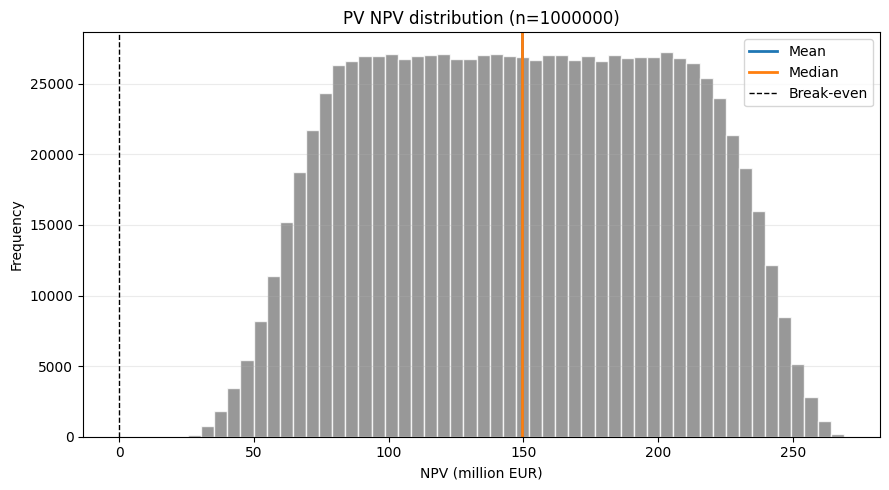

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"PV NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


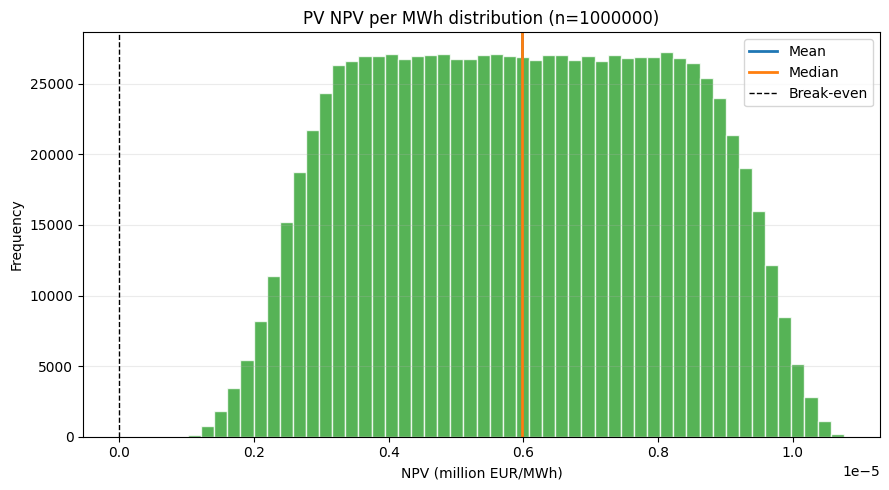

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"PV NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.07000
annual_fixed_opex_eur        12.40105
annual_variable_opex_eur      0.00000
annual_fuel_cost_eur          0.00000
annual_emissions_cost_eur     0.00000
annual_net_cash_flow_eur     81.66895
Name: Mean annual value, million EUR, dtype: float64